<a href="https://colab.research.google.com/github/rabiyy/weather/blob/main/Makine%C3%96%C4%9FrenmesiProje.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [85]:
df = pd.read_csv("/content/drive/MyDrive/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [86]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [87]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [89]:
df_sampled = df.sample(n=4000, random_state=42) # Rastgeleliği kontrol etmek için random_state ekledim
display(df_sampled.head())
display(f"Yeni veri çerçevesinin boyutu: {df_sampled.shape}")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
185,1024-GUALD,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,24.80,24.8,Yes
2715,0484-JPBRU,Male,0,No,No,41,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),25.25,996.45,No
3825,3620-EHIMZ,Female,0,Yes,Yes,52,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.35,1031.7,No
1807,6910-HADCM,Female,0,No,No,1,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,No,Electronic check,76.35,76.35,Yes
132,8587-XYZSF,Male,0,No,No,67,Yes,No,DSL,No,...,No,Yes,No,No,Two year,No,Bank transfer (automatic),50.55,3260.1,No


'Yeni veri çerçevesinin boyutu: (4000, 21)'

In [90]:
df = df_sampled

In [91]:
df.shape

(4000, 21)

In [92]:
#'customerID' sütununu sütun bazında (axis=1) siler
df = df.drop('customerID', axis=1, errors='ignore')

In [93]:
# Sayısallaştırma (Encoder)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4000 entries, 185 to 6204
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            4000 non-null   int64  
 1   SeniorCitizen     4000 non-null   int64  
 2   Partner           4000 non-null   int64  
 3   Dependents        4000 non-null   int64  
 4   tenure            4000 non-null   int64  
 5   PhoneService      4000 non-null   int64  
 6   MultipleLines     4000 non-null   int64  
 7   InternetService   4000 non-null   int64  
 8   OnlineSecurity    4000 non-null   int64  
 9   OnlineBackup      4000 non-null   int64  
 10  DeviceProtection  4000 non-null   int64  
 11  TechSupport       4000 non-null   int64  
 12  StreamingTV       4000 non-null   int64  
 13  StreamingMovies   4000 non-null   int64  
 14  Contract          4000 non-null   int64  
 15  PaperlessBilling  4000 non-null   int64  
 16  PaymentMethod     4000 non-null   int64  
 17

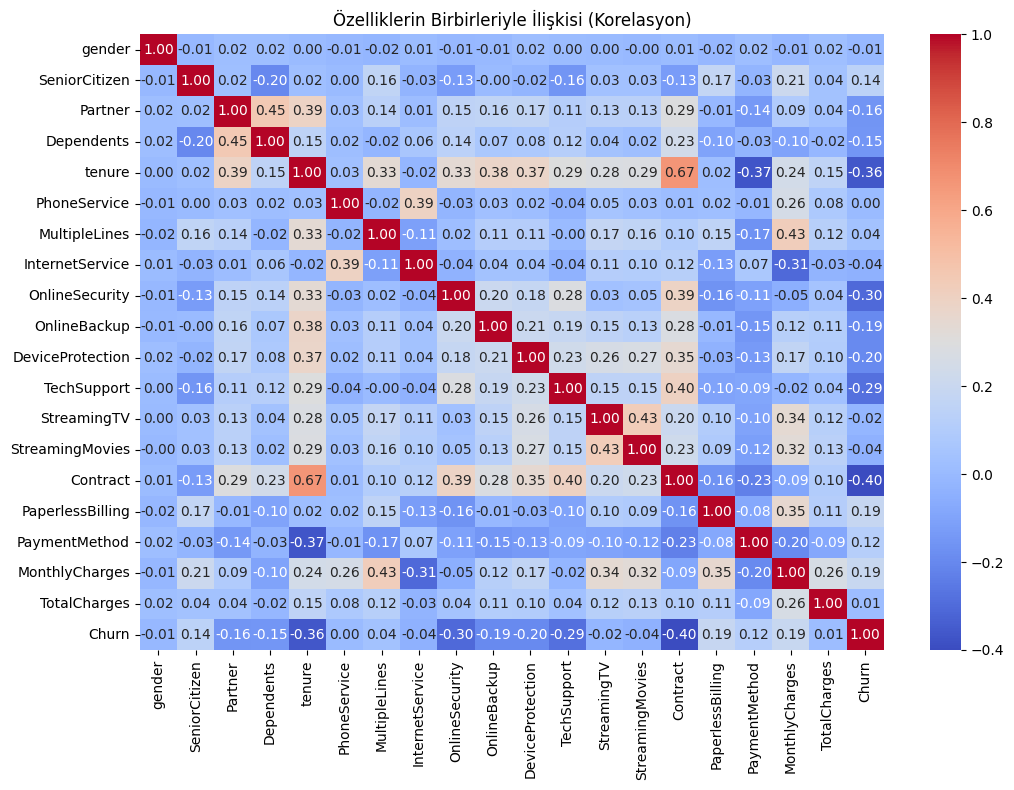

In [95]:
# Korelasyon Matrisi (Hangi özelliklerin Churn ile alakası var?)
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Özelliklerin Birbirleriyle İlişkisi (Korelasyon)")
plt.show()

In [96]:
print(df.corr() ['Churn'])

gender             -0.009954
SeniorCitizen       0.144489
Partner            -0.158985
Dependents         -0.152142
tenure             -0.362778
PhoneService        0.002344
MultipleLines       0.040941
InternetService    -0.042894
OnlineSecurity     -0.304332
OnlineBackup       -0.194679
DeviceProtection   -0.196055
TechSupport        -0.285570
StreamingTV        -0.019573
StreamingMovies    -0.042934
Contract           -0.401015
PaperlessBilling    0.185927
PaymentMethod       0.116123
MonthlyCharges      0.193254
TotalCharges        0.010181
Churn               1.000000
Name: Churn, dtype: float64


In [97]:
silinecekler = ['gender', 'PhoneService']

df = df.drop(columns=silinecekler, axis=1, errors='ignore')

In [98]:
df.shape

(4000, 18)

In [99]:
from sklearn.model_selection import train_test_split

# Tüm satırları al, ama son sütun hariç tüm sütunları al (-1 sonuncuyu hariç tutar)
X = df.iloc[:, :-1]
y = df['Churn']

# Veriyi %80 Eğitim, %20 Test olacak şekilde bölelim
# random_state=42 sayesinde her çalıştırdığında aynı satırlar aynı gruba gider
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)



In [100]:
print(f"Eğitim seti boyutu: {X_train.shape}")
print(f"Test seti boyutu: {X_test.shape}")

Eğitim seti boyutu: (3200, 17)
Test seti boyutu: (800, 17)


In [101]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Sadece X verilerini ölçeklendiriyoruz (y zaten 0 veya 1)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

LOGISTIC REGRESSION
Accuracy (Doğruluk): 0.8050
------------------------------
Detaylı Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87       591
           1       0.66      0.52      0.58       209

    accuracy                           0.81       800
   macro avg       0.75      0.71      0.73       800
weighted avg       0.79      0.81      0.80       800



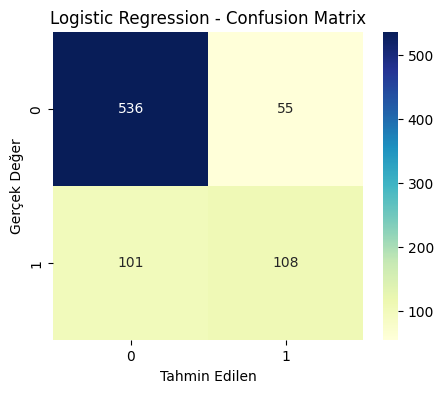

In [102]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

log_model = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='liblinear',
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

# Tahmin Yap
y_pred_log = log_model.predict(X_test_scaled)

log_acc = accuracy_score(y_test, y_pred_log)

print(f"LOGISTIC REGRESSION")
print(f"Accuracy (Doğruluk): {log_acc:.4f}")
print("-" * 30)
print("Detaylı Sınıflandırma Raporu:")
print(classification_report(y_test, y_pred_log))

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='YlGnBu')
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Tahmin Edilen")
plt.ylabel("Gerçek Değer")
plt.show()

Fitting 5 folds for each of 10 candidates, totalling 50 fits
En İyi Parametreler: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
En İyi CV Skoru: 0.8047

LOGISTIC REGRESSION (OPTIMIZED) RESULTS
Test Seti Doğruluğu: 0.8025
------------------------------


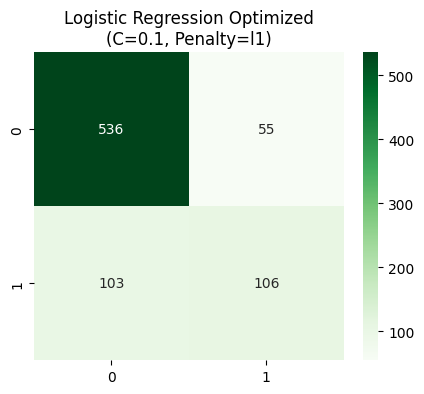

              precision    recall  f1-score   support

           0       0.84      0.91      0.87       591
           1       0.66      0.51      0.57       209

    accuracy                           0.80       800
   macro avg       0.75      0.71      0.72       800
weighted avg       0.79      0.80      0.79       800



In [103]:
from sklearn.model_selection import GridSearchCV

param_grid_log = {
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear']
}

grid_log = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid_log,
    cv=5,
    scoring='accuracy',
    verbose=1 # İşlem sürecini görmemizi sağlar
)

grid_log.fit(X_train_scaled, y_train)
print("En İyi Parametreler:", grid_log.best_params_)
print(f"En İyi CV Skoru: {grid_log.best_score_:.4f}")

#Tahmin
y_pred_log = grid_log.predict(X_test_scaled)
log_acc = accuracy_score(y_test, y_pred_log)

print(f"\nLOGISTIC REGRESSION (OPTIMIZED) RESULTS")
print(f"Test Seti Doğruluğu: {log_acc:.4f}")
print("-" * 30)

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Greens')
plt.title(f"Logistic Regression Optimized\n(C={grid_log.best_params_['C']}, Penalty={grid_log.best_params_['penalty']})")
plt.show()

print(classification_report(y_test, y_pred_log))


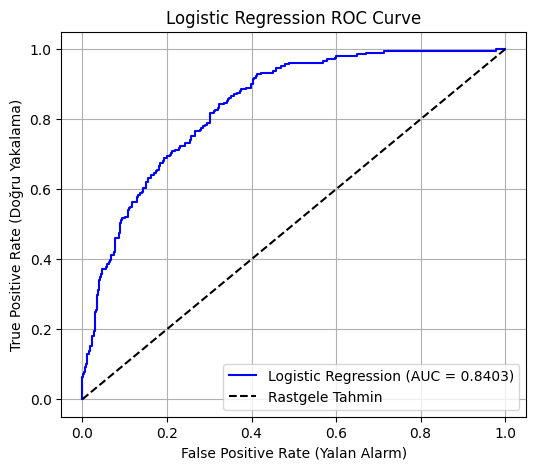

In [104]:
from sklearn.metrics import roc_curve, roc_auc_score

y_probs_log = log_model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs_log)
auc_score = roc_auc_score(y_test, y_probs_log)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.4f})', color='blue')
plt.plot([0, 1], [0, 1], 'k--', label='Rastgele Tahmin')
plt.xlabel('False Positive Rate (Yalan Alarm)')
plt.ylabel('True Positive Rate (Doğru Yakalama)')
plt.title('Logistic Regression ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

Fitting 5 folds for each of 108 candidates, totalling 540 fits
En İyi Parametreler: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}
En İyi CV Skoru: 0.7906

DECISION TREE (OPTIMIZED) RESULTS
Test Seti Doğruluğu: 0.7937
------------------------------


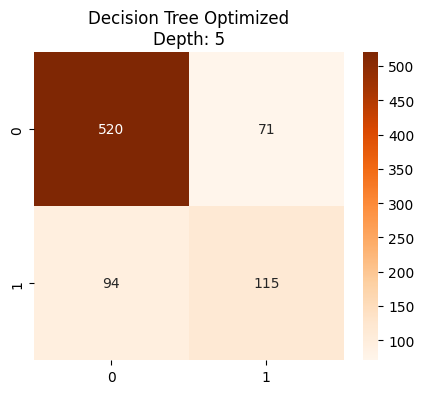

In [106]:
from sklearn.tree import DecisionTreeClassifier

param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 3, 5, 7, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='accuracy',
    verbose=1
)

grid_dt.fit(X_train_scaled, y_train)
print("En İyi Parametreler:", grid_dt.best_params_)
print(f"En İyi CV Skoru: {grid_dt.best_score_:.4f}")

# Tahmin ve Değerlendirme
y_pred_dt = grid_dt.predict(X_test_scaled)
dt_acc = accuracy_score(y_test, y_pred_dt)

print(f"\nDECISION TREE (OPTIMIZED) RESULTS")
print(f"Test Seti Doğruluğu: {dt_acc:.4f}")
print("-" * 30)

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Oranges')
plt.title(f"Decision Tree Optimized\nDepth: {grid_dt.best_params_['max_depth']}")
plt.show()

In [107]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.85      0.88      0.86       591
           1       0.62      0.55      0.58       209

    accuracy                           0.79       800
   macro avg       0.73      0.72      0.72       800
weighted avg       0.79      0.79      0.79       800



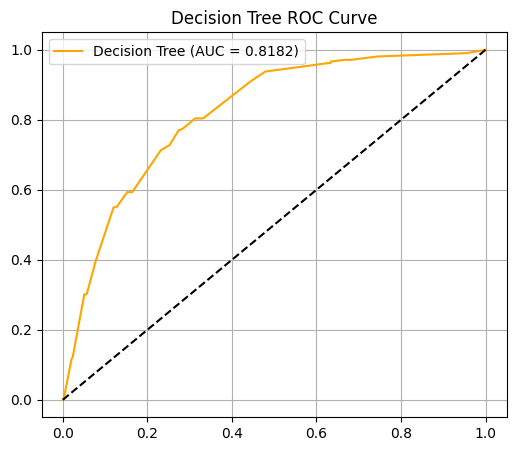

In [108]:
y_probs_dt = grid_dt.predict_proba(X_test_scaled)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_probs_dt)
auc_dt = roc_auc_score(y_test, y_probs_dt)

plt.figure(figsize=(6, 5))
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.4f})', color='orange')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Decision Tree ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
En İyi Parametreler: {'bootstrap': True, 'criterion': 'entropy', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 300}
En İyi CV Skoru: 0.8081

RANDOM FOREST (OPTIMIZED) RESULTS
Test Seti Doğruluğu: 0.8075
------------------------------


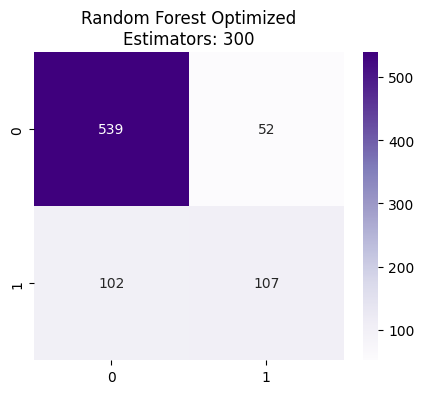

              precision    recall  f1-score   support

           0       0.84      0.91      0.88       591
           1       0.67      0.51      0.58       209

    accuracy                           0.81       800
   macro avg       0.76      0.71      0.73       800
weighted avg       0.80      0.81      0.80       800



In [109]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    verbose=1
)

grid_rf.fit(X_train_scaled, y_train)
print("En İyi Parametreler:", grid_rf.best_params_)
print(f"En İyi CV Skoru: {grid_rf.best_score_:.4f}")

# Tahmin ve Sonuçlar
y_pred_rf = grid_rf.predict(X_test_scaled)
rf_acc = accuracy_score(y_test, y_pred_rf)

print(f"\nRANDOM FOREST (OPTIMIZED) RESULTS")
print(f"Test Seti Doğruluğu: {rf_acc:.4f}")
print("-" * 30)

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Purples')
plt.title(f"Random Forest Optimized\nEstimators: {grid_rf.best_params_['n_estimators']}")
plt.show()

print(classification_report(y_test, y_pred_rf))


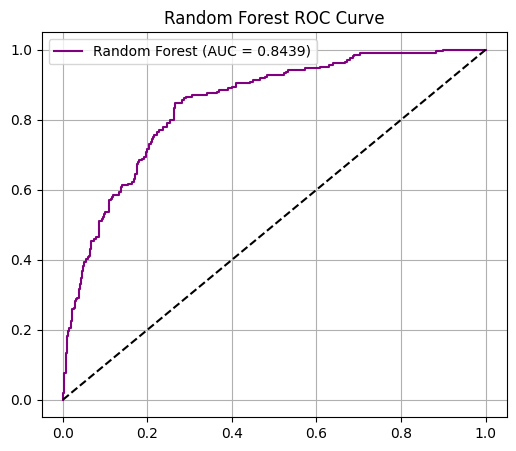

In [110]:
y_probs_rf = grid_rf.predict_proba(X_test_scaled)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_probs_rf)
auc_rf = roc_auc_score(y_test, y_probs_rf)

plt.figure(figsize=(6, 5))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.4f})', color='purple')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Random Forest ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

Fitting 5 folds for each of 96 candidates, totalling 480 fits
En İyi SVM Parametreleri: {'C': 1, 'degree': 2, 'gamma': 'scale', 'kernel': 'linear'}
En İyi CV Skoru: 0.8019

SVM (OPTIMIZED) RESULTS
Test Seti Doğruluğu: 0.7875
------------------------------


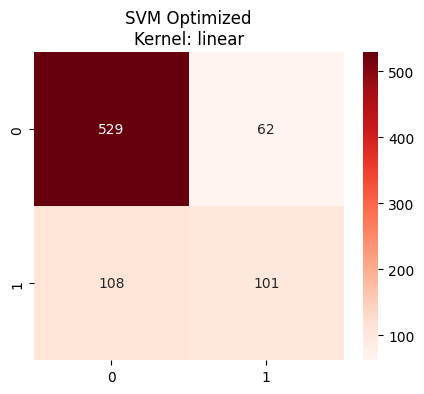

              precision    recall  f1-score   support

           0       0.83      0.90      0.86       591
           1       0.62      0.48      0.54       209

    accuracy                           0.79       800
   macro avg       0.73      0.69      0.70       800
weighted avg       0.78      0.79      0.78       800



In [111]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.1, 0.01],
    'degree': [2, 3] # Sadece poly kernel seçilirse devreye girer
}

grid_svm = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid_svm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_svm.fit(X_train_scaled, y_train)
print("En İyi SVM Parametreleri:", grid_svm.best_params_)
print(f"En İyi CV Skoru: {grid_svm.best_score_:.4f}")

#Tahmin
y_pred_svm = grid_svm.predict(X_test_scaled)
svm_acc = accuracy_score(y_test, y_pred_svm)

print(f"\nSVM (OPTIMIZED) RESULTS")
print(f"Test Seti Doğruluğu: {svm_acc:.4f}")
print("-" * 30)

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Reds')
plt.title(f"SVM Optimized\nKernel: {grid_svm.best_params_['kernel']}")
plt.show()

print(classification_report(y_test, y_pred_svm))

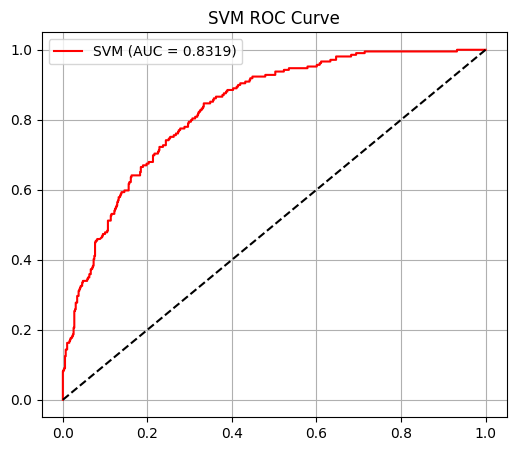

In [38]:
y_probs_svm = grid_svm.predict_proba(X_test_scaled)[:, 1]
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_probs_svm)
auc_svm = roc_auc_score(y_test, y_probs_svm)

plt.figure(figsize=(6, 5))
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.4f})', color='red')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('SVM ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

Fitting 5 folds for each of 162 candidates, totalling 810 fits
En İyi KNN Parametreleri: {'leaf_size': 20, 'metric': 'manhattan', 'n_neighbors': 19, 'weights': 'uniform'}
En İyi CV Skoru: 0.7888

KNN (OPTIMIZED) RESULTS
Test Seti Doğruluğu: 0.7863
------------------------------


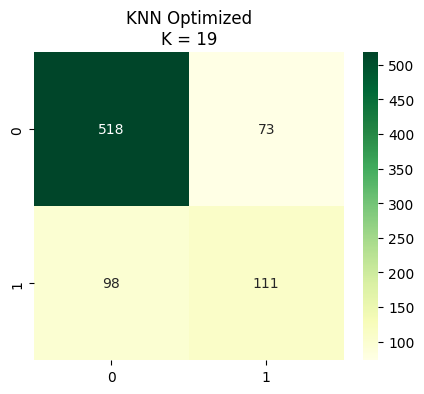

              precision    recall  f1-score   support

           0       0.84      0.88      0.86       591
           1       0.60      0.53      0.56       209

    accuracy                           0.79       800
   macro avg       0.72      0.70      0.71       800
weighted avg       0.78      0.79      0.78       800



In [29]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15, 19, 25],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'], # Minkowski p=2 iken euclidean olur
    'leaf_size': [20, 30, 40] # Ağaç bazlı aramalarda düğüm boyutu
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_knn.fit(X_train_scaled, y_train)

print("En İyi KNN Parametreleri:", grid_knn.best_params_)
print(f"En İyi CV Skoru: {grid_knn.best_score_:.4f}")

#Tahmin ve Sonuçlar
y_pred_knn = grid_knn.predict(X_test_scaled)
knn_acc = accuracy_score(y_test, y_pred_knn)

print(f"\nKNN (OPTIMIZED) RESULTS")
print(f"Test Seti Doğruluğu: {knn_acc:.4f}")
print("-" * 30)

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='YlGn')
plt.title(f"KNN Optimized\nK = {grid_knn.best_params_['n_neighbors']}")
plt.show()

print(classification_report(y_test, y_pred_knn))

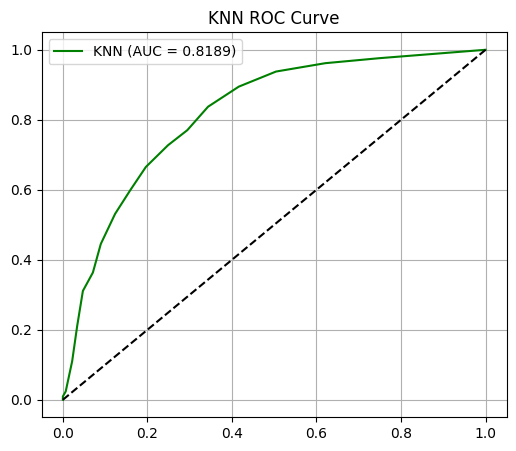

In [46]:
y_probs_knn = grid_knn.predict_proba(X_test_scaled)[:, 1]
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_probs_knn)
auc_knn = roc_auc_score(y_test, y_probs_knn)

plt.figure(figsize=(6, 5))
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.4f})', color='green')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('KNN ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

In [26]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 9.6 MB/s eta 0:00:00


In [27]:
import optuna
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

def objective(trial):
    kernel = trial.suggest_categorical('kernel', ['linear', 'rbf', 'poly'])
    c = trial.suggest_float('C', 0.1, 50.0, log=True)
    gamma = trial.suggest_categorical('gamma', ['scale', 'auto'])
    degree = trial.suggest_int('degree', 2, 4) if kernel == 'poly' else 3

    model = SVC(
        kernel=kernel,
        C=c,
        gamma=gamma,
        degree=degree,
        probability=True,
        random_state=42
    )

    score = cross_val_score(model, X_train_scaled, y_train, cv=5)
    return score.mean()

# Bir "çalışma" (study) oluştur ve 30 deneme yap (Süreyi korumak için 30 ideal)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print("\n" + "="*30)
print("OPTUNA SVM SONUCU")
print(f"En İyi Parametreler: {study.best_params}")
print(f"En İyi Doğruluk Skoru: {study.best_value:.4f}")
print("="*30)

[I 2026-04-25 10:36:16,942] A new study created in memory with name: no-name-6e493597-de16-4f38-ab13-72f26a1aea9b
[I 2026-04-25 10:36:21,993] Trial 0 finished with value: 0.7959375 and parameters: {'kernel': 'rbf', 'C': 1.07872098155489, 'gamma': 'scale'}. Best is trial 0 with value: 0.7959375.
[I 2026-04-25 10:36:30,491] Trial 1 finished with value: 0.7796875 and parameters: {'kernel': 'rbf', 'C': 6.49874401624488, 'gamma': 'scale'}. Best is trial 0 with value: 0.7959375.
[I 2026-04-25 10:36:35,256] Trial 2 finished with value: 0.794375 and parameters: {'kernel': 'rbf', 'C': 0.249134282064466, 'gamma': 'auto'}. Best is trial 0 with value: 0.7959375.
[I 2026-04-25 10:36:43,784] Trial 3 finished with value: 0.7821874999999998 and parameters: {'kernel': 'rbf', 'C': 4.173400783643358, 'gamma': 'auto'}. Best is trial 0 with value: 0.7959375.
[I 2026-04-25 10:36:50,162] Trial 4 finished with value: 0.7784374999999999 and parameters: {'kernel': 'rbf', 'C': 6.985441323797081, 'gamma': 'scale'


OPTUNA SVM SONUCU
En İyi Parametreler: {'kernel': 'linear', 'C': 2.296862335252356, 'gamma': 'scale'}
En İyi Doğruluk Skoru: 0.8019


ALGORİTMA: SVM (OPTUNA OPTIMIZED)
En İyi Parametreler: {'kernel': 'linear', 'C': 2.296862335252356, 'gamma': 'scale'}
Accuracy (Doğruluk): 0.7863
ROC-AUC Skoru: 0.8318
------------------------------
              precision    recall  f1-score   support

           0       0.83      0.89      0.86       591
           1       0.62      0.48      0.54       209

    accuracy                           0.79       800
   macro avg       0.72      0.69      0.70       800
weighted avg       0.77      0.79      0.78       800



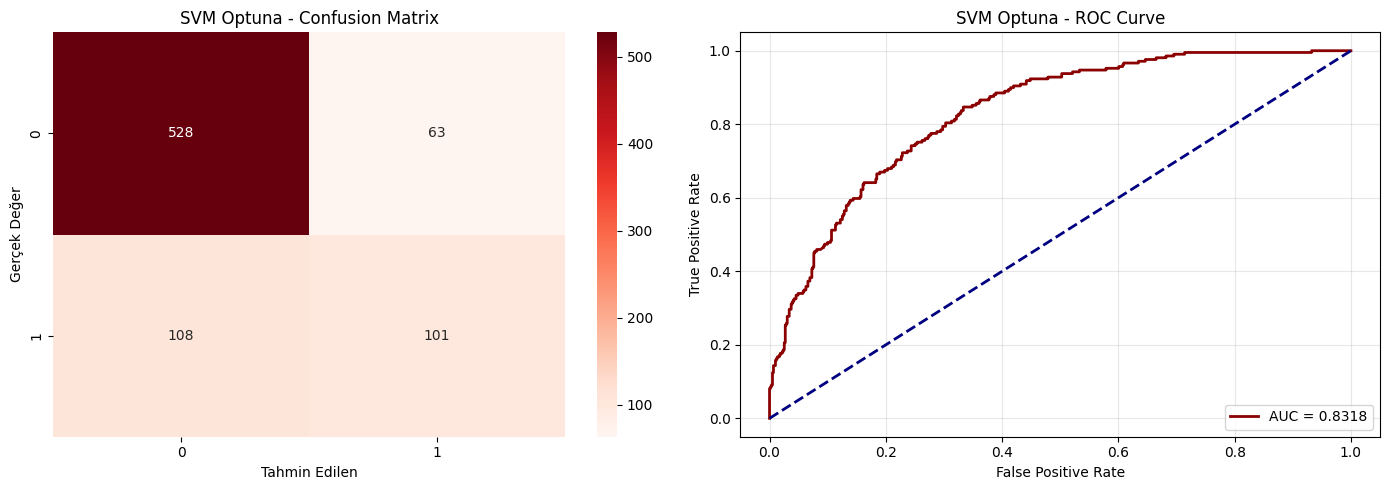

In [45]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt

best_params = study.best_params

if best_params.get('kernel') != 'poly' and 'degree' in best_params:
    best_params_clean = {k: v for k, v in best_params.items() if k != 'degree'}
else:
    best_params_clean = best_params

final_svm_optuna = SVC(**best_params_clean, probability=True, random_state=42)
final_svm_optuna.fit(X_train_scaled, y_train)

y_pred_svm_opt = final_svm_optuna.predict(X_test_scaled)
y_probs_svm_opt = final_svm_optuna.predict_proba(X_test_scaled)[:, 1]

svm_opt_acc = accuracy_score(y_test, y_pred_svm_opt)
fpr, tpr, _ = roc_curve(y_test, y_probs_svm_opt)
roc_auc_svm_opt = auc(fpr, tpr)

print(f"ALGORİTMA: SVM (OPTUNA OPTIMIZED)")
print(f"En İyi Parametreler: {best_params_clean}")
print(f"Accuracy (Doğruluk): {svm_opt_acc:.4f}")
print(f"ROC-AUC Skoru: {roc_auc_svm_opt:.4f}")
print("-" * 30)
print(classification_report(y_test, y_pred_svm_opt))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_svm_opt), annot=True, fmt='d', cmap='Reds', ax=ax[0])
ax[0].set_title("SVM Optuna - Confusion Matrix")
ax[0].set_xlabel("Tahmin Edilen")
ax[0].set_ylabel("Gerçek Değer")

# ROC Curve
ax[1].plot(fpr, tpr, color='darkred', lw=2, label=f'AUC = {roc_auc_svm_opt:.4f}')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_title("SVM Optuna - ROC Curve")
ax[1].set_xlabel("False Positive Rate")
ax[1].set_ylabel("True Positive Rate")
ax[1].legend(loc="lower right")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Fitting 5 folds for each of 40 candidates, totalling 200 fits
En İyi AdaBoost Parametreleri: {'estimator': DecisionTreeClassifier(max_depth=2), 'learning_rate': 0.05, 'n_estimators': 500}
En İyi CV Skoru: 0.8078

ADABOOST (OPTIMIZED) RESULTS
Test Seti Doğruluğu: 0.8000
------------------------------


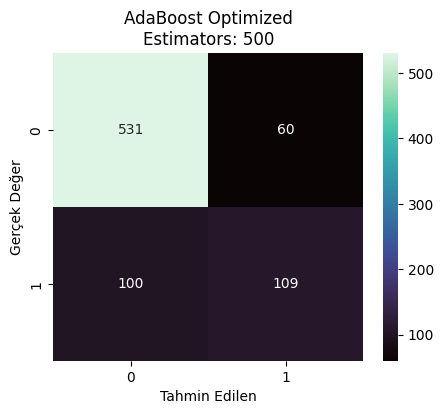

              precision    recall  f1-score   support

           0       0.84      0.90      0.87       591
           1       0.64      0.52      0.58       209

    accuracy                           0.80       800
   macro avg       0.74      0.71      0.72       800
weighted avg       0.79      0.80      0.79       800



In [28]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

param_grid_ada = {
    'n_estimators': [50, 100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0],
    'estimator': [DecisionTreeClassifier(max_depth=1), DecisionTreeClassifier(max_depth=2)]
}

grid_ada = GridSearchCV(
    AdaBoostClassifier(random_state=42),
    param_grid_ada,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_ada.fit(X_train_scaled, y_train)

print("En İyi AdaBoost Parametreleri:", grid_ada.best_params_)
print(f"En İyi CV Skoru: {grid_ada.best_score_:.4f}")

# Tahmin
y_pred_ada = grid_ada.predict(X_test_scaled)
ada_acc = accuracy_score(y_test, y_pred_ada)

print(f"\nADABOOST (OPTIMIZED) RESULTS")
print(f"Test Seti Doğruluğu: {ada_acc:.4f}")
print("-" * 30)

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_ada), annot=True, fmt='d', cmap='mako')
plt.title(f"AdaBoost Optimized\nEstimators: {grid_ada.best_params_['n_estimators']}")
plt.xlabel("Tahmin Edilen")
plt.ylabel("Gerçek Değer")
plt.show()

print(classification_report(y_test, y_pred_ada))

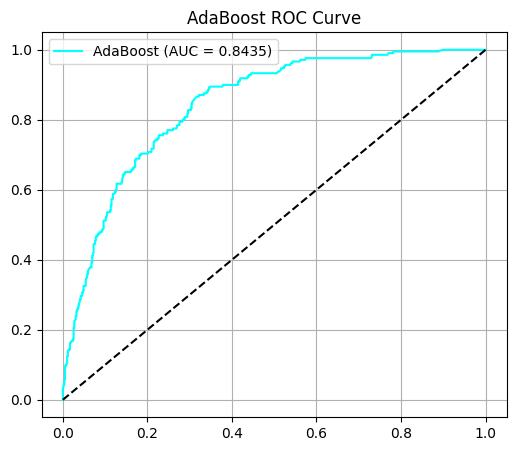

In [47]:
y_probs_ada = grid_ada.predict_proba(X_test_scaled)[:, 1]
fpr_ada, tpr_ada, _ = roc_curve(y_test, y_probs_ada)
auc_ada = roc_auc_score(y_test, y_probs_ada)

plt.figure(figsize=(6, 5))
plt.plot(fpr_ada, tpr_ada, label=f'AdaBoost (AUC = {auc_ada:.4f})', color='cyan')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('AdaBoost ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

En İyi var_smoothing: 1.0
En İyi CV Skoru: 0.7706

--- NAIVE BAYES FINAL SONUÇLARI ---
Test Seti Doğruluğu: 0.7638
------------------------------


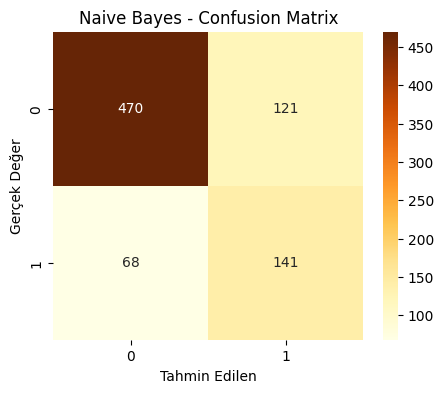

              precision    recall  f1-score   support

           0       0.87      0.80      0.83       591
           1       0.54      0.67      0.60       209

    accuracy                           0.76       800
   macro avg       0.71      0.73      0.72       800
weighted avg       0.79      0.76      0.77       800



In [33]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV

param_grid_nb = {
    'var_smoothing': np.logspace(0, -9, num=100)
}

grid_nb = GridSearchCV(
    GaussianNB(),
    param_grid_nb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_nb.fit(X_train_scaled, y_train)

print(f"En İyi var_smoothing: {grid_nb.best_params_['var_smoothing']}")
print(f"En İyi CV Skoru: {grid_nb.best_score_:.4f}")

# Tahmin
y_pred_nb = grid_nb.predict(X_test_scaled)
nb_acc = accuracy_score(y_test, y_pred_nb)

print("\n--- NAIVE BAYES FINAL SONUÇLARI ---")
print(f"Test Seti Doğruluğu: {nb_acc:.4f}")
print("-" * 30)

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d', cmap='YlOrBr')
plt.title("Naive Bayes - Confusion Matrix")
plt.xlabel("Tahmin Edilen")
plt.ylabel("Gerçek Değer")
plt.show()

print(classification_report(y_test, y_pred_nb))

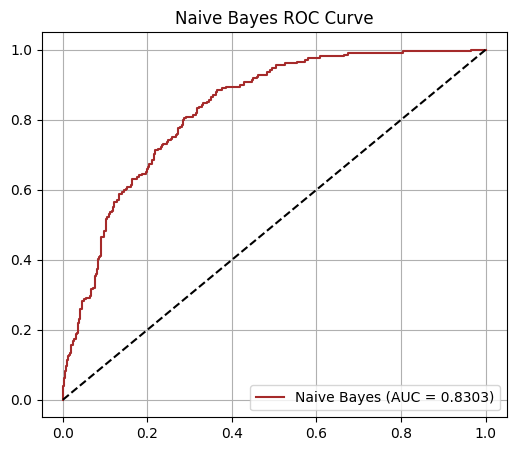

In [48]:
y_probs_nb = grid_nb.predict_proba(X_test_scaled)[:, 1]
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_probs_nb)
auc_nb = roc_auc_score(y_test, y_probs_nb)

plt.figure(figsize=(6, 5))
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {auc_nb:.4f})', color='brown')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Naive Bayes ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_2245/2015072976.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=comparison_df, palette='viridis')


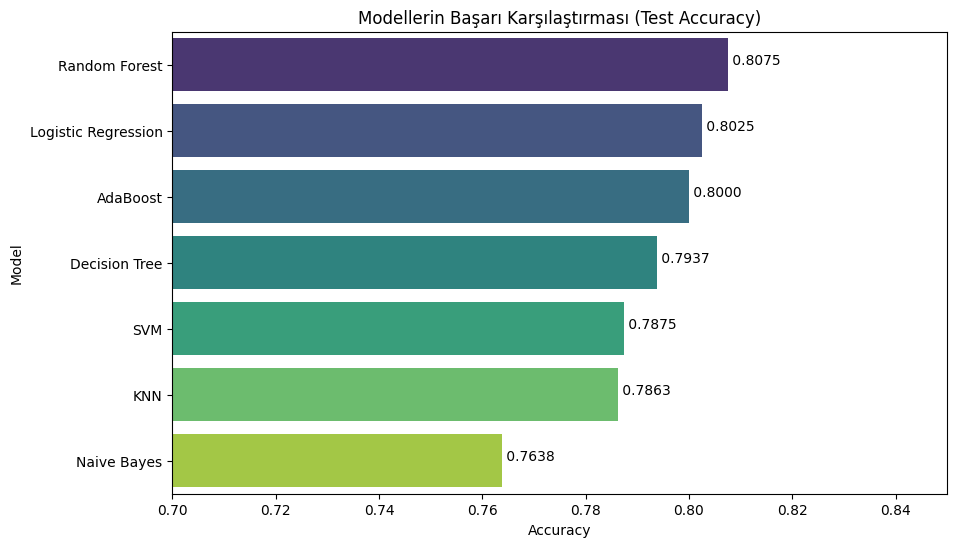

                 Model  Accuracy
2        Random Forest   0.80750
0  Logistic Regression   0.80250
5             AdaBoost   0.80000
1        Decision Tree   0.79375
3                  SVM   0.78750
4                  KNN   0.78625
6          Naive Bayes   0.76375


In [34]:
import pandas as pd

# Her modelin en iyi doğruluk skorları
final_results = {
    "Logistic Regression": log_acc,
    "Decision Tree": dt_acc,
    "Random Forest": rf_acc,
    "SVM": svm_acc,
    "KNN": knn_acc,
    "AdaBoost": ada_acc,
    "Naive Bayes": nb_acc
}

comparison_df = pd.DataFrame(list(final_results.items()), columns=['Model', 'Accuracy'])
comparison_df = comparison_df.sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=comparison_df, palette='viridis')
plt.title('Modellerin Başarı Karşılaştırması (Test Accuracy)')
plt.xlim(0.7, 0.85)
for index, value in enumerate(comparison_df.Accuracy):
    plt.text(value, index, f' {value:.4f}')
plt.show()

print(comparison_df)

/tmp/ipykernel_2245/677482988.py:22: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




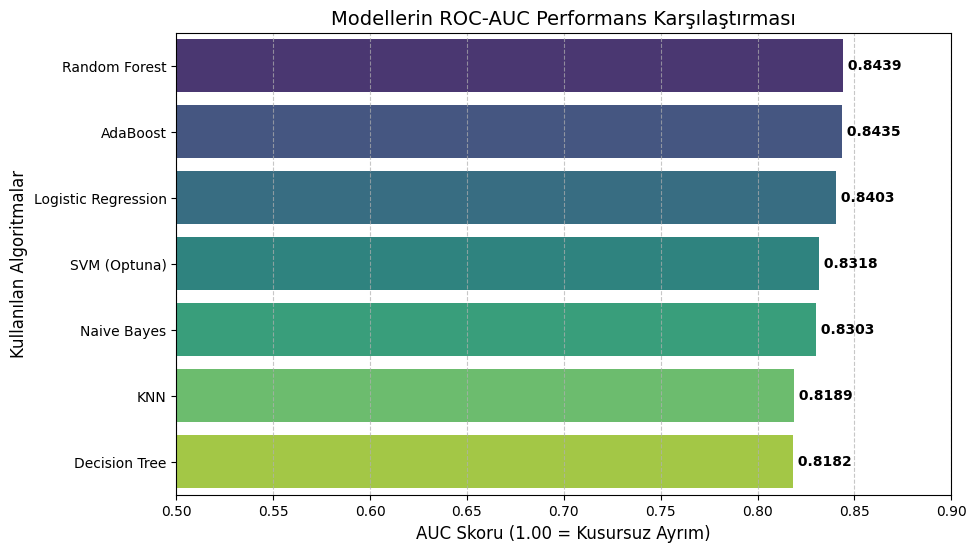

                 Model  AUC_Score
2        Random Forest   0.843894
5             AdaBoost   0.843522
0  Logistic Regression   0.840348
3         SVM (Optuna)   0.831775
6          Naive Bayes   0.830285
4                  KNN   0.818874
1        Decision Tree   0.818238


In [50]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

auc_scores = {
    "Logistic Regression": roc_auc_score(y_test, log_model.predict_proba(X_test_scaled)[:, 1]),
    "Decision Tree": roc_auc_score(y_test, grid_dt.predict_proba(X_test_scaled)[:, 1]),
    "Random Forest": roc_auc_score(y_test, grid_rf.predict_proba(X_test_scaled)[:, 1]),
    "SVM (Optuna)": roc_auc_score(y_test, final_svm_optuna.predict_proba(X_test_scaled)[:, 1]),
    "KNN": roc_auc_score(y_test, grid_knn.predict_proba(X_test_scaled)[:, 1]),
    "AdaBoost": roc_auc_score(y_test, grid_ada.predict_proba(X_test_scaled)[:, 1]),
    "Naive Bayes": roc_auc_score(y_test, grid_nb.predict_proba(X_test_scaled)[:, 1])
}

auc_df = pd.DataFrame(list(auc_scores.items()), columns=['Model', 'AUC_Score'])
auc_df = auc_df.sort_values(by='AUC_Score', ascending=False)

plt.figure(figsize=(10, 6))
colors = sns.color_palette("viridis", len(auc_df)) # Şık bir renk paleti

bar_plot = sns.barplot(x='AUC_Score', y='Model', data=auc_df, palette=colors)

for index, value in enumerate(auc_df.AUC_Score):
    plt.text(value, index, f' {value:.4f}', va='center', fontweight='bold')

plt.title('Modellerin ROC-AUC Performans Karşılaştırması', fontsize=14)
plt.xlabel('AUC Skoru (1.00 = Kusursuz Ayrım)', fontsize=12)
plt.ylabel('Kullanılan Algoritmalar', fontsize=12)
plt.xlim(0.5, 0.9) # Farkları net görmek için ekseni 0.5'ten başlat
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print(auc_df)